In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")

from yahooquery import Ticker
from datetime import datetime

# List of top 10 IT sector companies in India by market capitalization
tech_list = [
    "TCS.NS",       # Tata Consultancy Services
    "INFY.NS",      # Infosys Limited
    "HCLTECH.NS",   # HCL Technologies
    "WIPRO.NS",     # Wipro Limited
    "LTIM.NS",      # LTIMindtree Ltd.
    "TECHM.NS",     # Tech Mahindra Ltd.
    "OFSS.NS",      # Oracle Financial Services Software Ltd.
    "PERSISTENT.NS",# Persistent Systems Ltd.
    "MPHASIS.NS",   # MphasiS Ltd.
    "COFORGE.NS"    # Coforge Ltd.
]

# Corresponding company names
company_name = [
    "Tata Consultancy Services",
    "Infosys Limited",
    "HCL Technologies",
    "Wipro Limited",
    "LTIMindtree Ltd.",
    "Tech Mahindra Ltd.",
    "Oracle Financial Services Software Ltd.",
    "Persistent Systems Ltd.",
    "MphasiS Ltd.",
    "Coforge Ltd."
]

end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

# Dictionary to store stock data
stock_data = {}

for i, ticker in enumerate(tech_list):
    var_name = ticker.replace(".", "_")   # like earlier
    t = Ticker(ticker)
    df = t.history(start=start.strftime("%Y-%m-%d"),
                   end=end.strftime("%Y-%m-%d"),
                   interval="1d")  # daily candles

    # yahooquery returns a multi-index DataFrame (symbol + date),
    # so reset index for consistency
    df = df.reset_index(level=0, drop=True).reset_index()
    df = df.rename(columns={"symbol": "Ticker"})
    df["Company"] = company_name[i]

    stock_data[var_name] = df

company_list = list(stock_data.values())
print(company_list)


[           date         open         high          low        close   volume  \
0    2024-08-19  4421.000000  4494.250000  4390.350098  4490.000000  2055210   
1    2024-08-20  4505.000000  4565.000000  4500.000000  4523.299805  2212298   
2    2024-08-21  4518.000000  4560.000000  4492.549805  4551.500000  1896990   
3    2024-08-22  4560.000000  4560.950195  4497.200195  4502.000000  1829872   
4    2024-08-23  4500.000000  4506.000000  4455.000000  4463.899902  1809253   
..          ...          ...          ...          ...          ...      ...   
244  2025-08-08  3048.100098  3059.800049  3025.000000  3036.399902  2762140   
245  2025-08-11  3036.399902  3049.899902  3021.300049  3040.800049  1884215   
246  2025-08-12  3041.000000  3096.399902  3026.899902  3035.399902  3358232   
247  2025-08-13  3036.100098  3044.399902  3028.600098  3036.199951  2148166   
248  2025-08-14  3034.000000  3055.899902  3019.100098  3022.300049  3342174   

        adjclose  dividends           

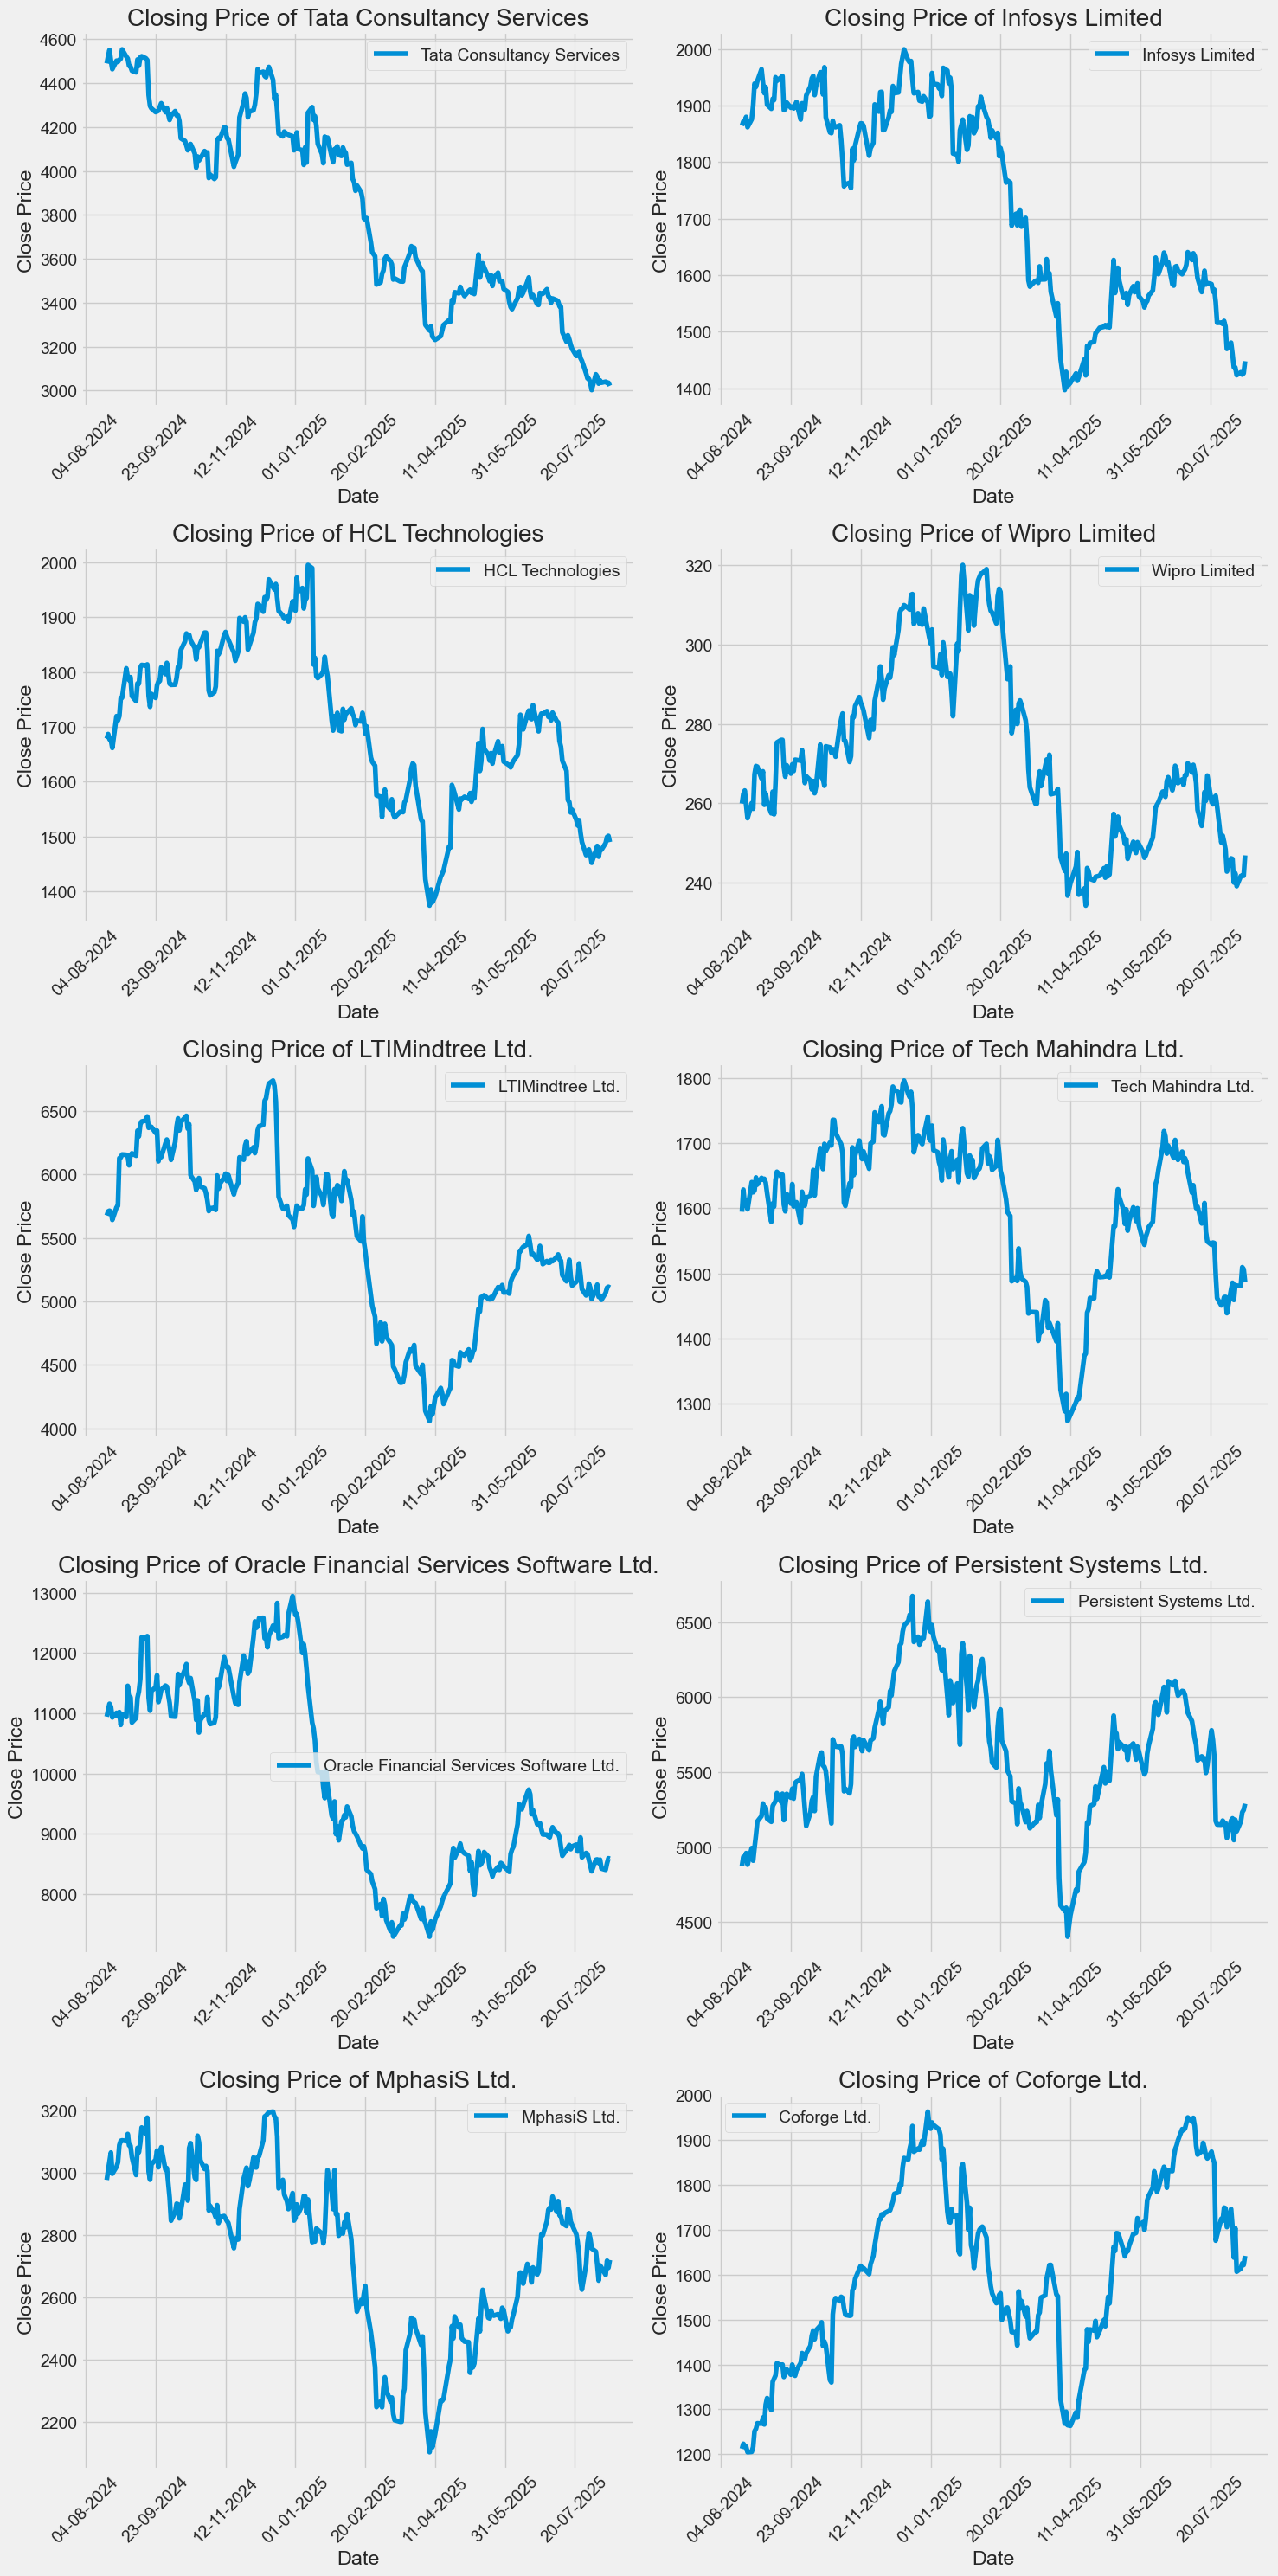

In [55]:
#Plotting an example for closing price of all the stock under observation
import matplotlib.dates as mdates
plt.figure(figsize=(15, 30))
plt.subplots_adjust(top=1.25, bottom=1.2)
for i, company in enumerate(company_list, 1):
    plt.subplot(5, 2, i) 
    plt.plot(company['date'], company["close"], label=company_name[i - 1])
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))  # Format dates
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=50))  # Show every 30th day
    plt.xticks(rotation=45)  # Rotate date labels for better readability
    plt.ylabel("Close Price")
    plt.xlabel("Date")
    plt.title(f"Closing Price of {company_name[i - 1]}")
    plt.legend()

plt.tight_layout()
plt.show()

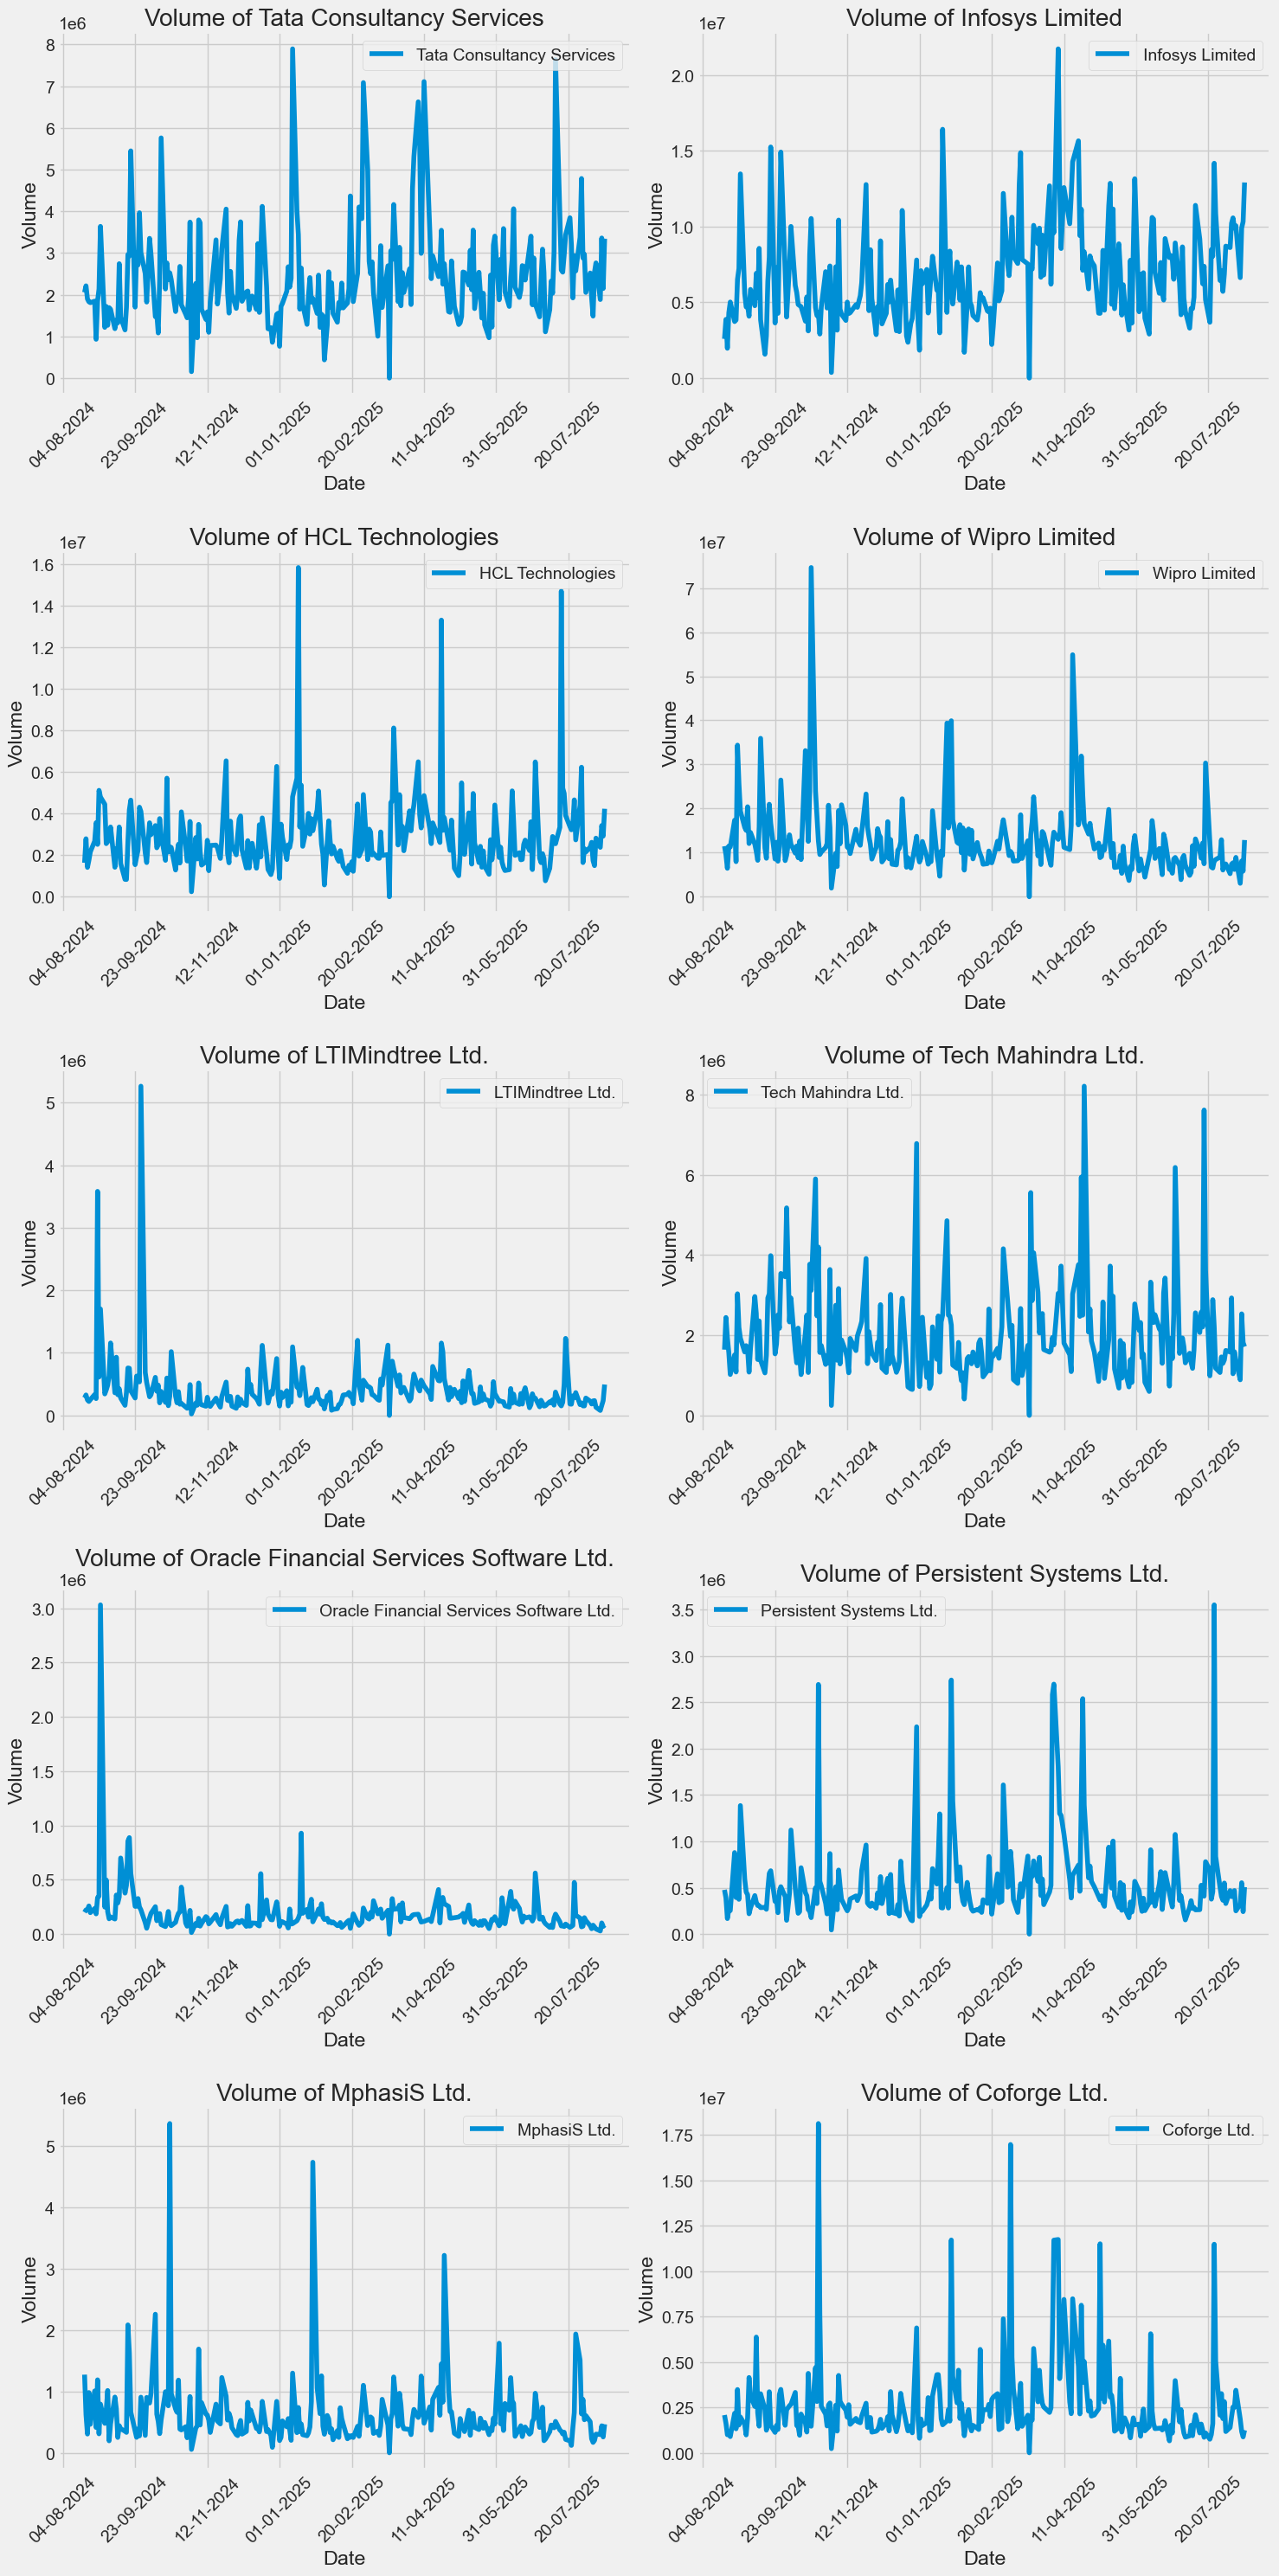

In [ ]:
# Now let's plot the total volume of stock being traded each day
plt.figure(figsize=(15, 30))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(5, 2, i)
    plt.plot(company["date"], company["volume"], label=company_name[i - 1])
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=50))  # Show every 50th day
    plt.xticks(rotation=45)  # Rotate date labels for better readability
    plt.ylabel("Volume")
    plt.xlabel("Date")
    plt.title(f"Volume of {company_name[i - 1]}")
    plt.legend()

plt.tight_layout()
plt.show()

Moving averages:

Basically there are major three types of moving averages 
1. Simple Moving average
2. Exponential Moving average
3. Weighted moving average

Simple Moving average(SMA): 
It is the average value(arithmetic mean) of the sliding window. It smooths noise but it lags since it treats all the prices equally.
Example: if last 5 days price was 100,101,102,103,104 then SMA for 5 days will be 102.

Exponential Moving average(EMA):
It assigns Exponential weights to prices to calculate averages. The recent prices have higher weights and decreases Exponentially. All prices are considered.
EMA(t​)=α⋅P(t​)+(1−α)⋅EMA(t−1​) where α=2/(n+1).
Example: if n=3 and α=0.5 ema depends half on today and half on yesterday's ema

Weighted Moving average(WMA):
It assigns linear weights to prices to calculate averages. The recent prices have higher weights and decreases lineraly. Only n prices are considered rest are taken zero.
Used for short term trading where recent prices only have effects.
WMA(t)=n*P(t)+(n-1)*P(t-1).....1*P(t-n-1) /n


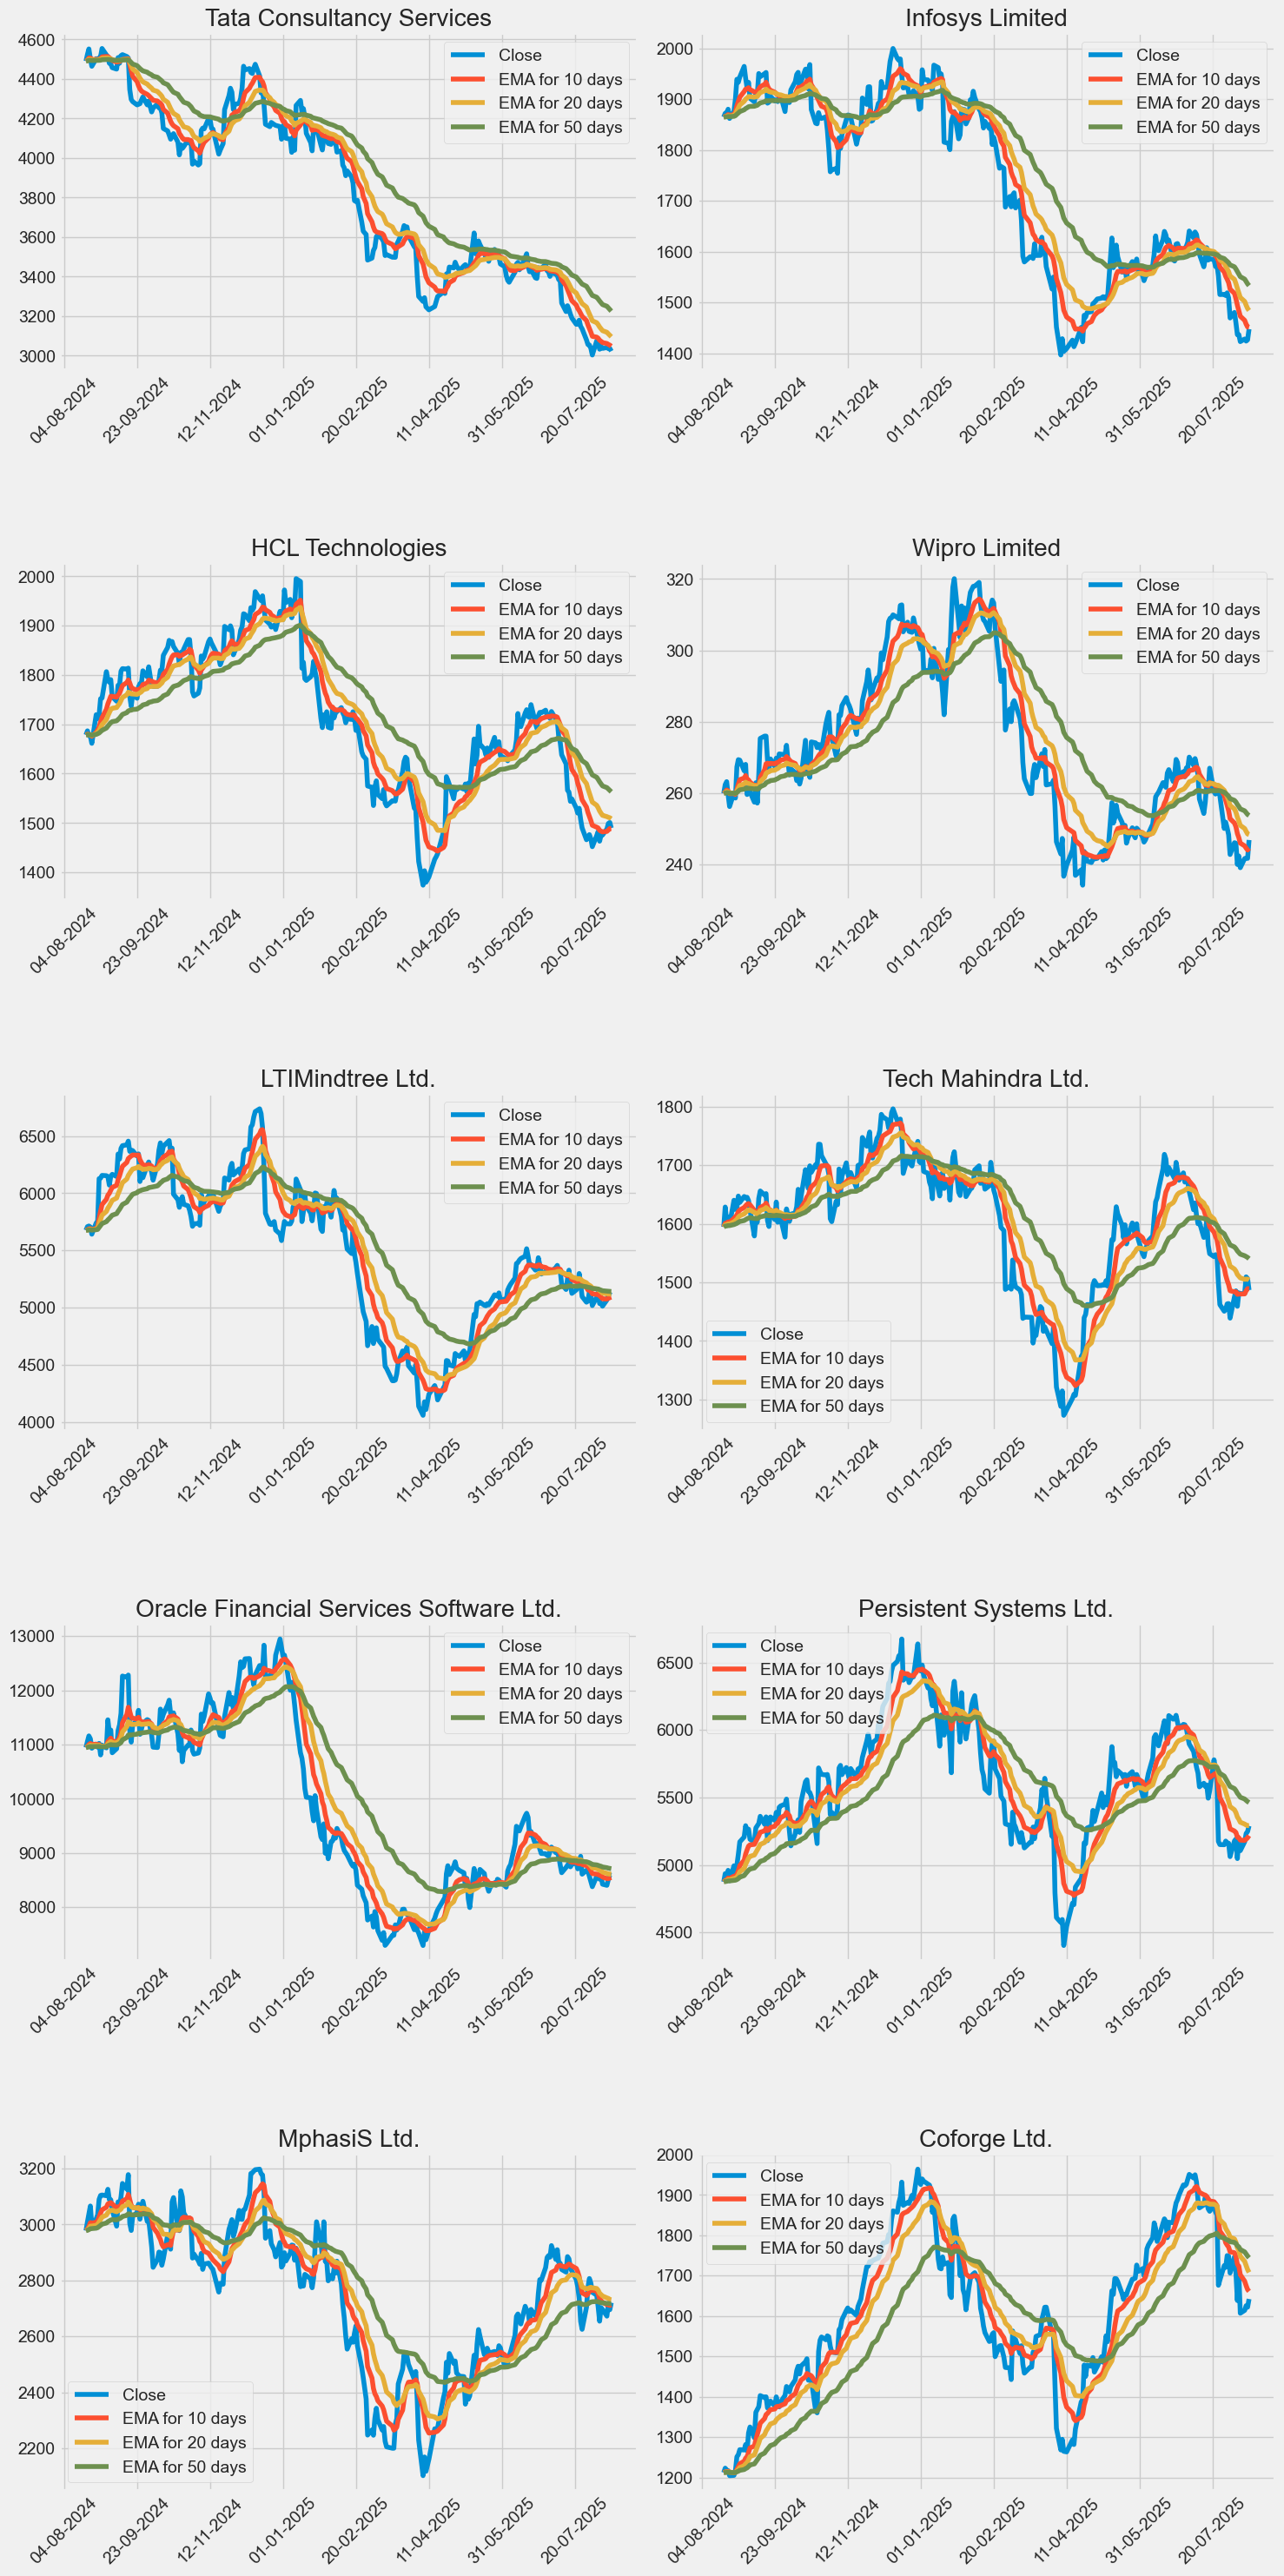

In [ ]:

#Calculating moving averages over different time periods of 10,20 and 50 days
#The Moving Average is a simple technical analysis tool that smooths out price data by creating a constantly updated average price.

ma_day = [10, 20, 50]
for ma in ma_day:
    for company in company_list:
        column_name = f"EMA for {ma} days"
        company[column_name] = company['close'].ewm(span=ma, adjust=False,min_periods=1).mean() #Calculating EMA for long term calculation!
        # company[column_name] = company['Close'].rolling(ma).mean() can be used for SMA        
plt.figure(figsize=(15,30))
plt.subplots_adjust(top=1.25, bottom=1.2)
for i,company in enumerate(company_list,1):
    plt.subplot(5,2,i)
    plt.plot(company["date"],company['close'],label='Close')
    plt.plot(company["date"],company['EMA for 10 days'],label='EMA for 10 days')
    plt.plot(company["date"],company['EMA for 20 days'],label='EMA for 20 days')
    plt.plot(company["date"],company['EMA for 50 days'],label='EMA for 50 days')
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=50))
    plt.xticks(rotation=45)  
    plt.title(company_name[i-1])
    plt.legend()
plt.tight_layout()


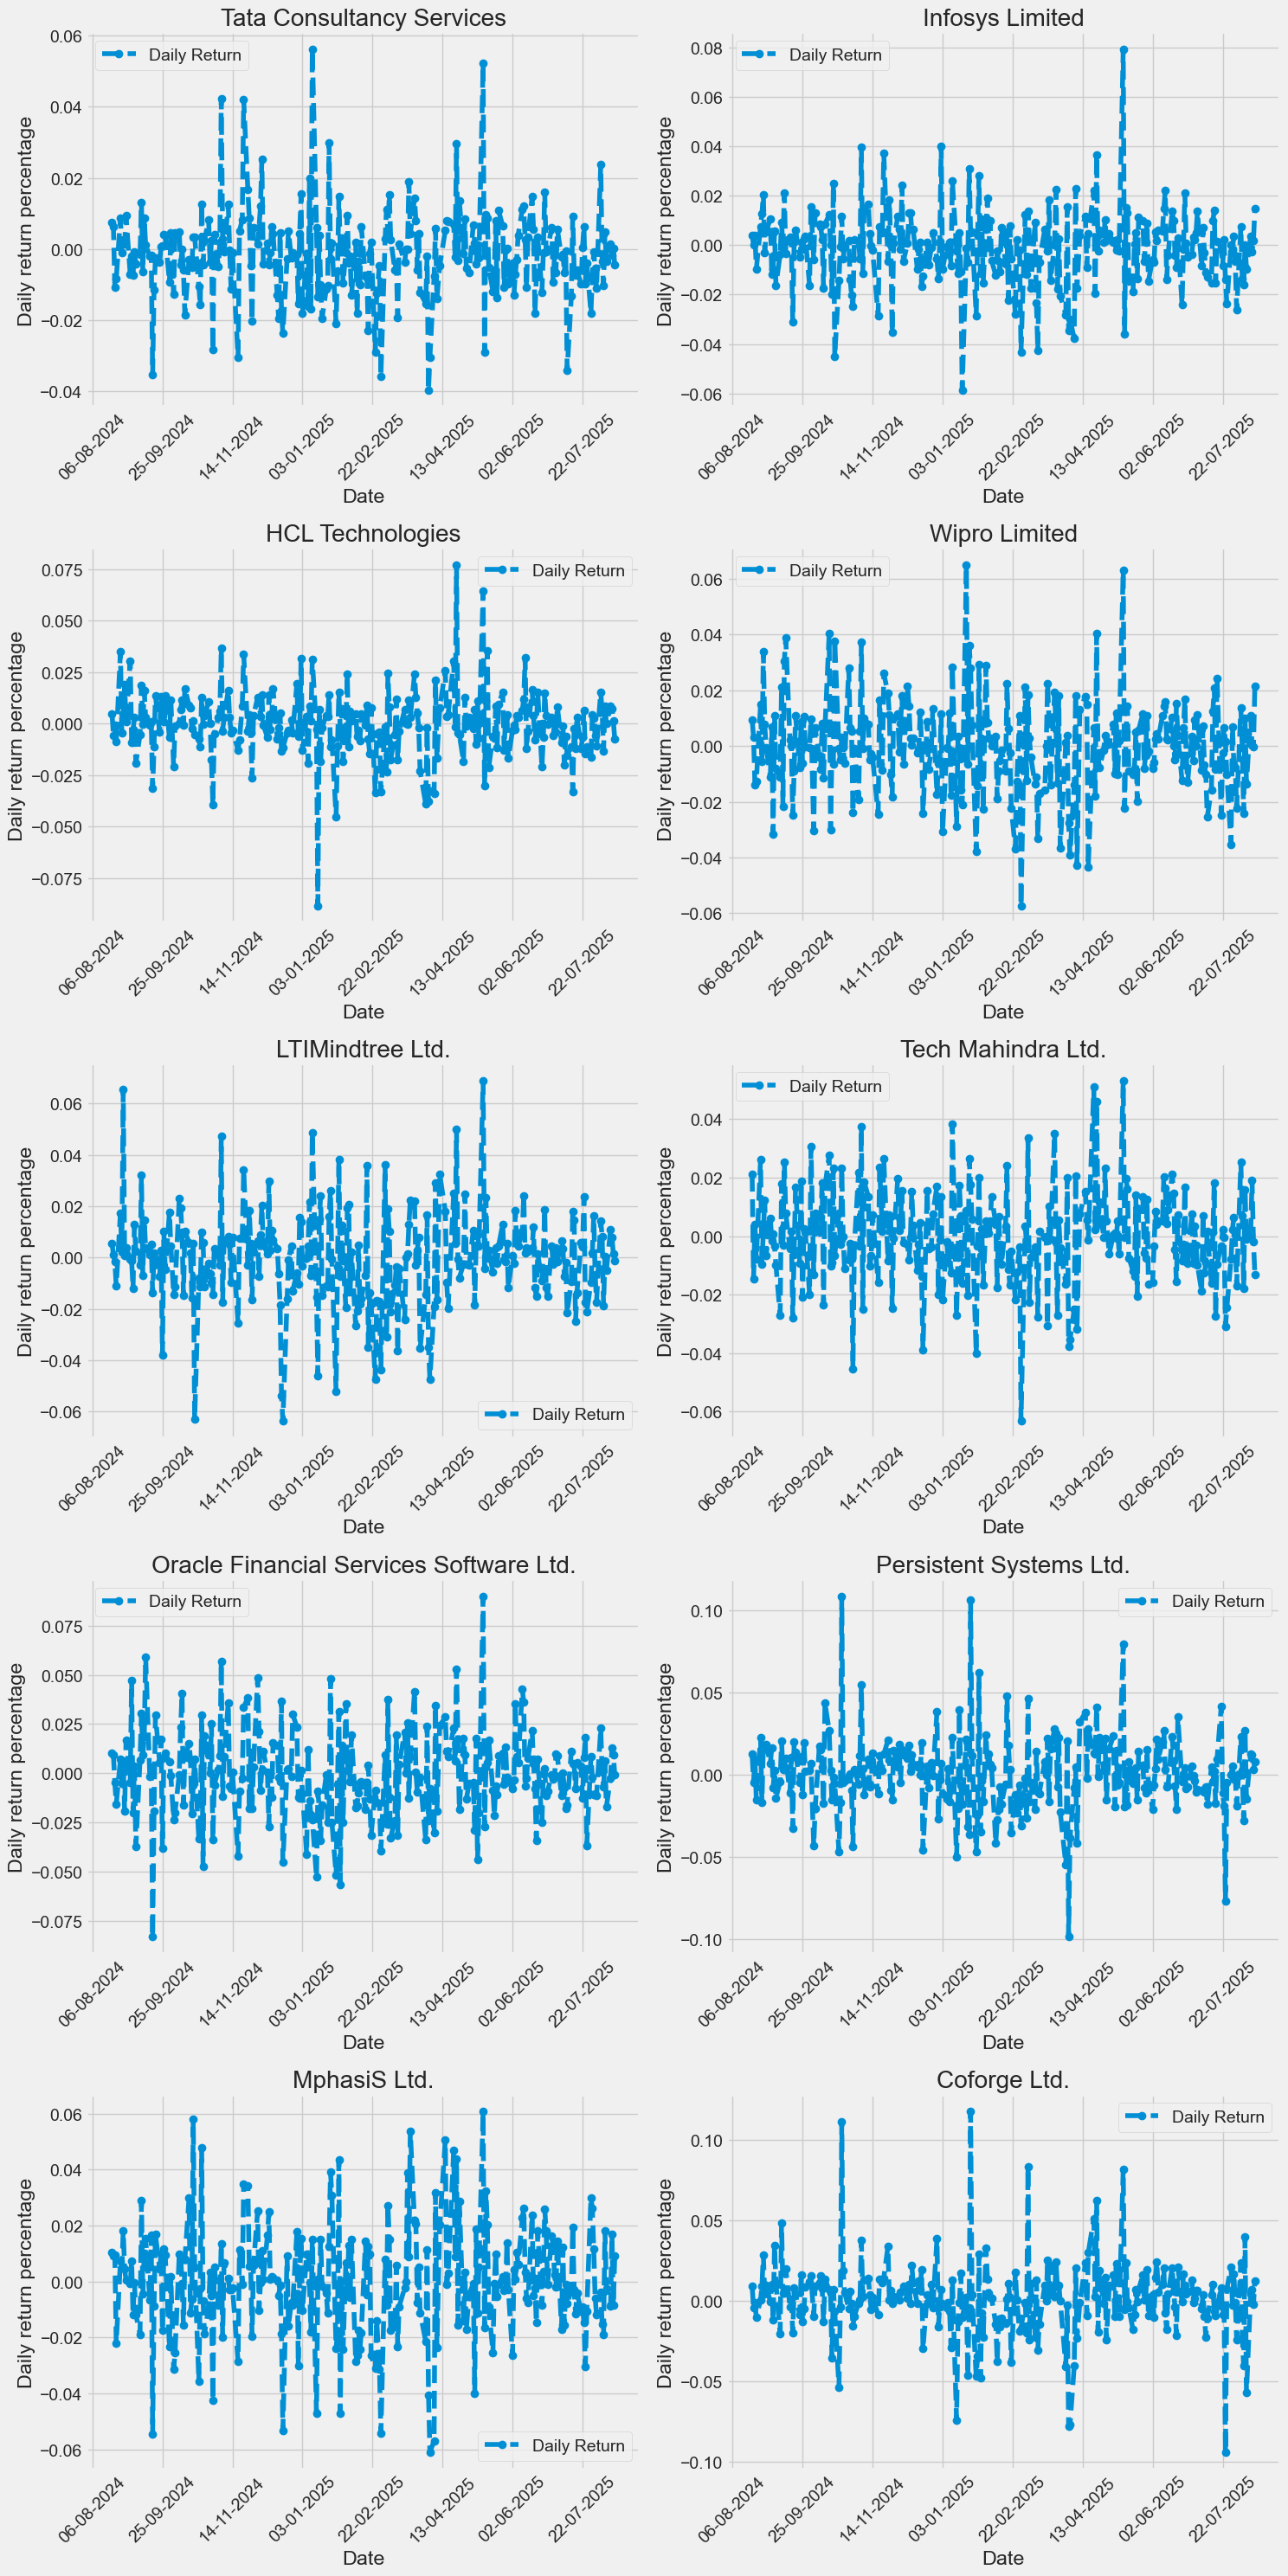

In [ ]:
# We'll use pct_change to find the percent change for each day
for company in company_list:
    company['Daily Return'] = company['close'].pct_change()

# Then we'll plot the daily return percentage
plt.figure(figsize=(15,30))
plt.subplots_adjust(top=1.25, bottom=1.2)
for i,company in enumerate(company_list,1):
    plt.subplot(5,2,i)
    plt.plot(company["date"],company['Daily Return'],label='Daily Return',linestyle='--',marker='o')
    plt.xlabel("Date")
    plt.ylabel("Daily return percentage")
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=50))
    plt.xticks(rotation=45)
    plt.title(company_name[i-1])
    plt.legend()
plt.tight_layout()

In [ ]:
# Collect all the closing prices for the tech stock list into one DataFrame
tickers = Ticker(tech_list)
history = tickers.history(start=start, end=end)
history = history.reset_index()
history = history[['date', 'symbol', 'close']]
closing_df = history.pivot(index='date', columns='symbol', values='close')
print(closing_df.head())
# Make a new tech returns DataFrame
tech_rets = closing_df.pct_change()
print(tech_rets)


symbol       COFORGE.NS   HCLTECH.NS      INFY.NS      LTIM.NS   MPHASIS.NS  \
date                                                                          
2024-08-19  1211.930054  1678.500000  1864.800049  5676.100098  2977.699951   
2024-08-20  1223.050049  1686.750000  1872.199951  5707.799805  3008.949951   
2024-08-21  1218.069946  1677.250000  1872.699951  5713.450195  3036.949951   
2024-08-22  1216.839966  1676.150024  1880.250000  5704.399902  3065.649902   
2024-08-23  1204.449951  1661.449951  1862.099976  5641.600098  2997.649902   

symbol           OFSS.NS  PERSISTENT.NS       TCS.NS     TECHM.NS    WIPRO.NS  
date                                                                           
2024-08-19  10944.150391    4874.500000  4490.000000  1594.650024  259.875000  
2024-08-20  11056.700195    4935.149902  4523.299805  1628.599976  262.325012  
2024-08-21  11158.000000    4912.600098  4551.500000  1604.650024  263.174988  
2024-08-22  11106.049805    4959.750000  4502.

C:\Users\moksh\AppData\Local\Temp\ipykernel_5944\2385172921.py:10: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  tech_rets = closing_df.pct_change()


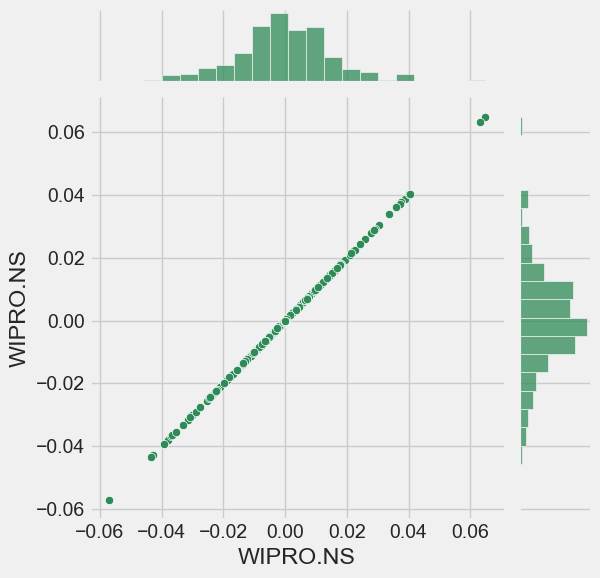

In [60]:
# Comparing Wipro to itself should show a perfectly linear relationship
sns.jointplot(x='WIPRO.NS', y='WIPRO.NS', data=tech_rets, kind='scatter', color='seagreen')

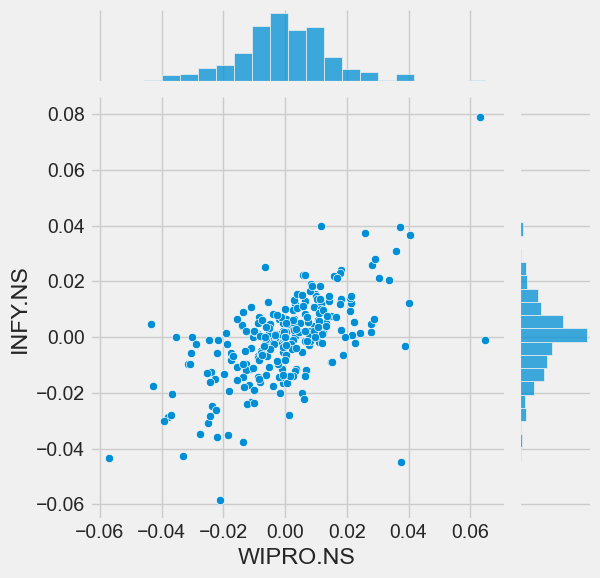

In [ ]:
sns.jointplot(x='WIPRO.NS', y='INFY.NS', data=tech_rets, kind='scatter')#Comparing Wipro with Infosys to know relation between them

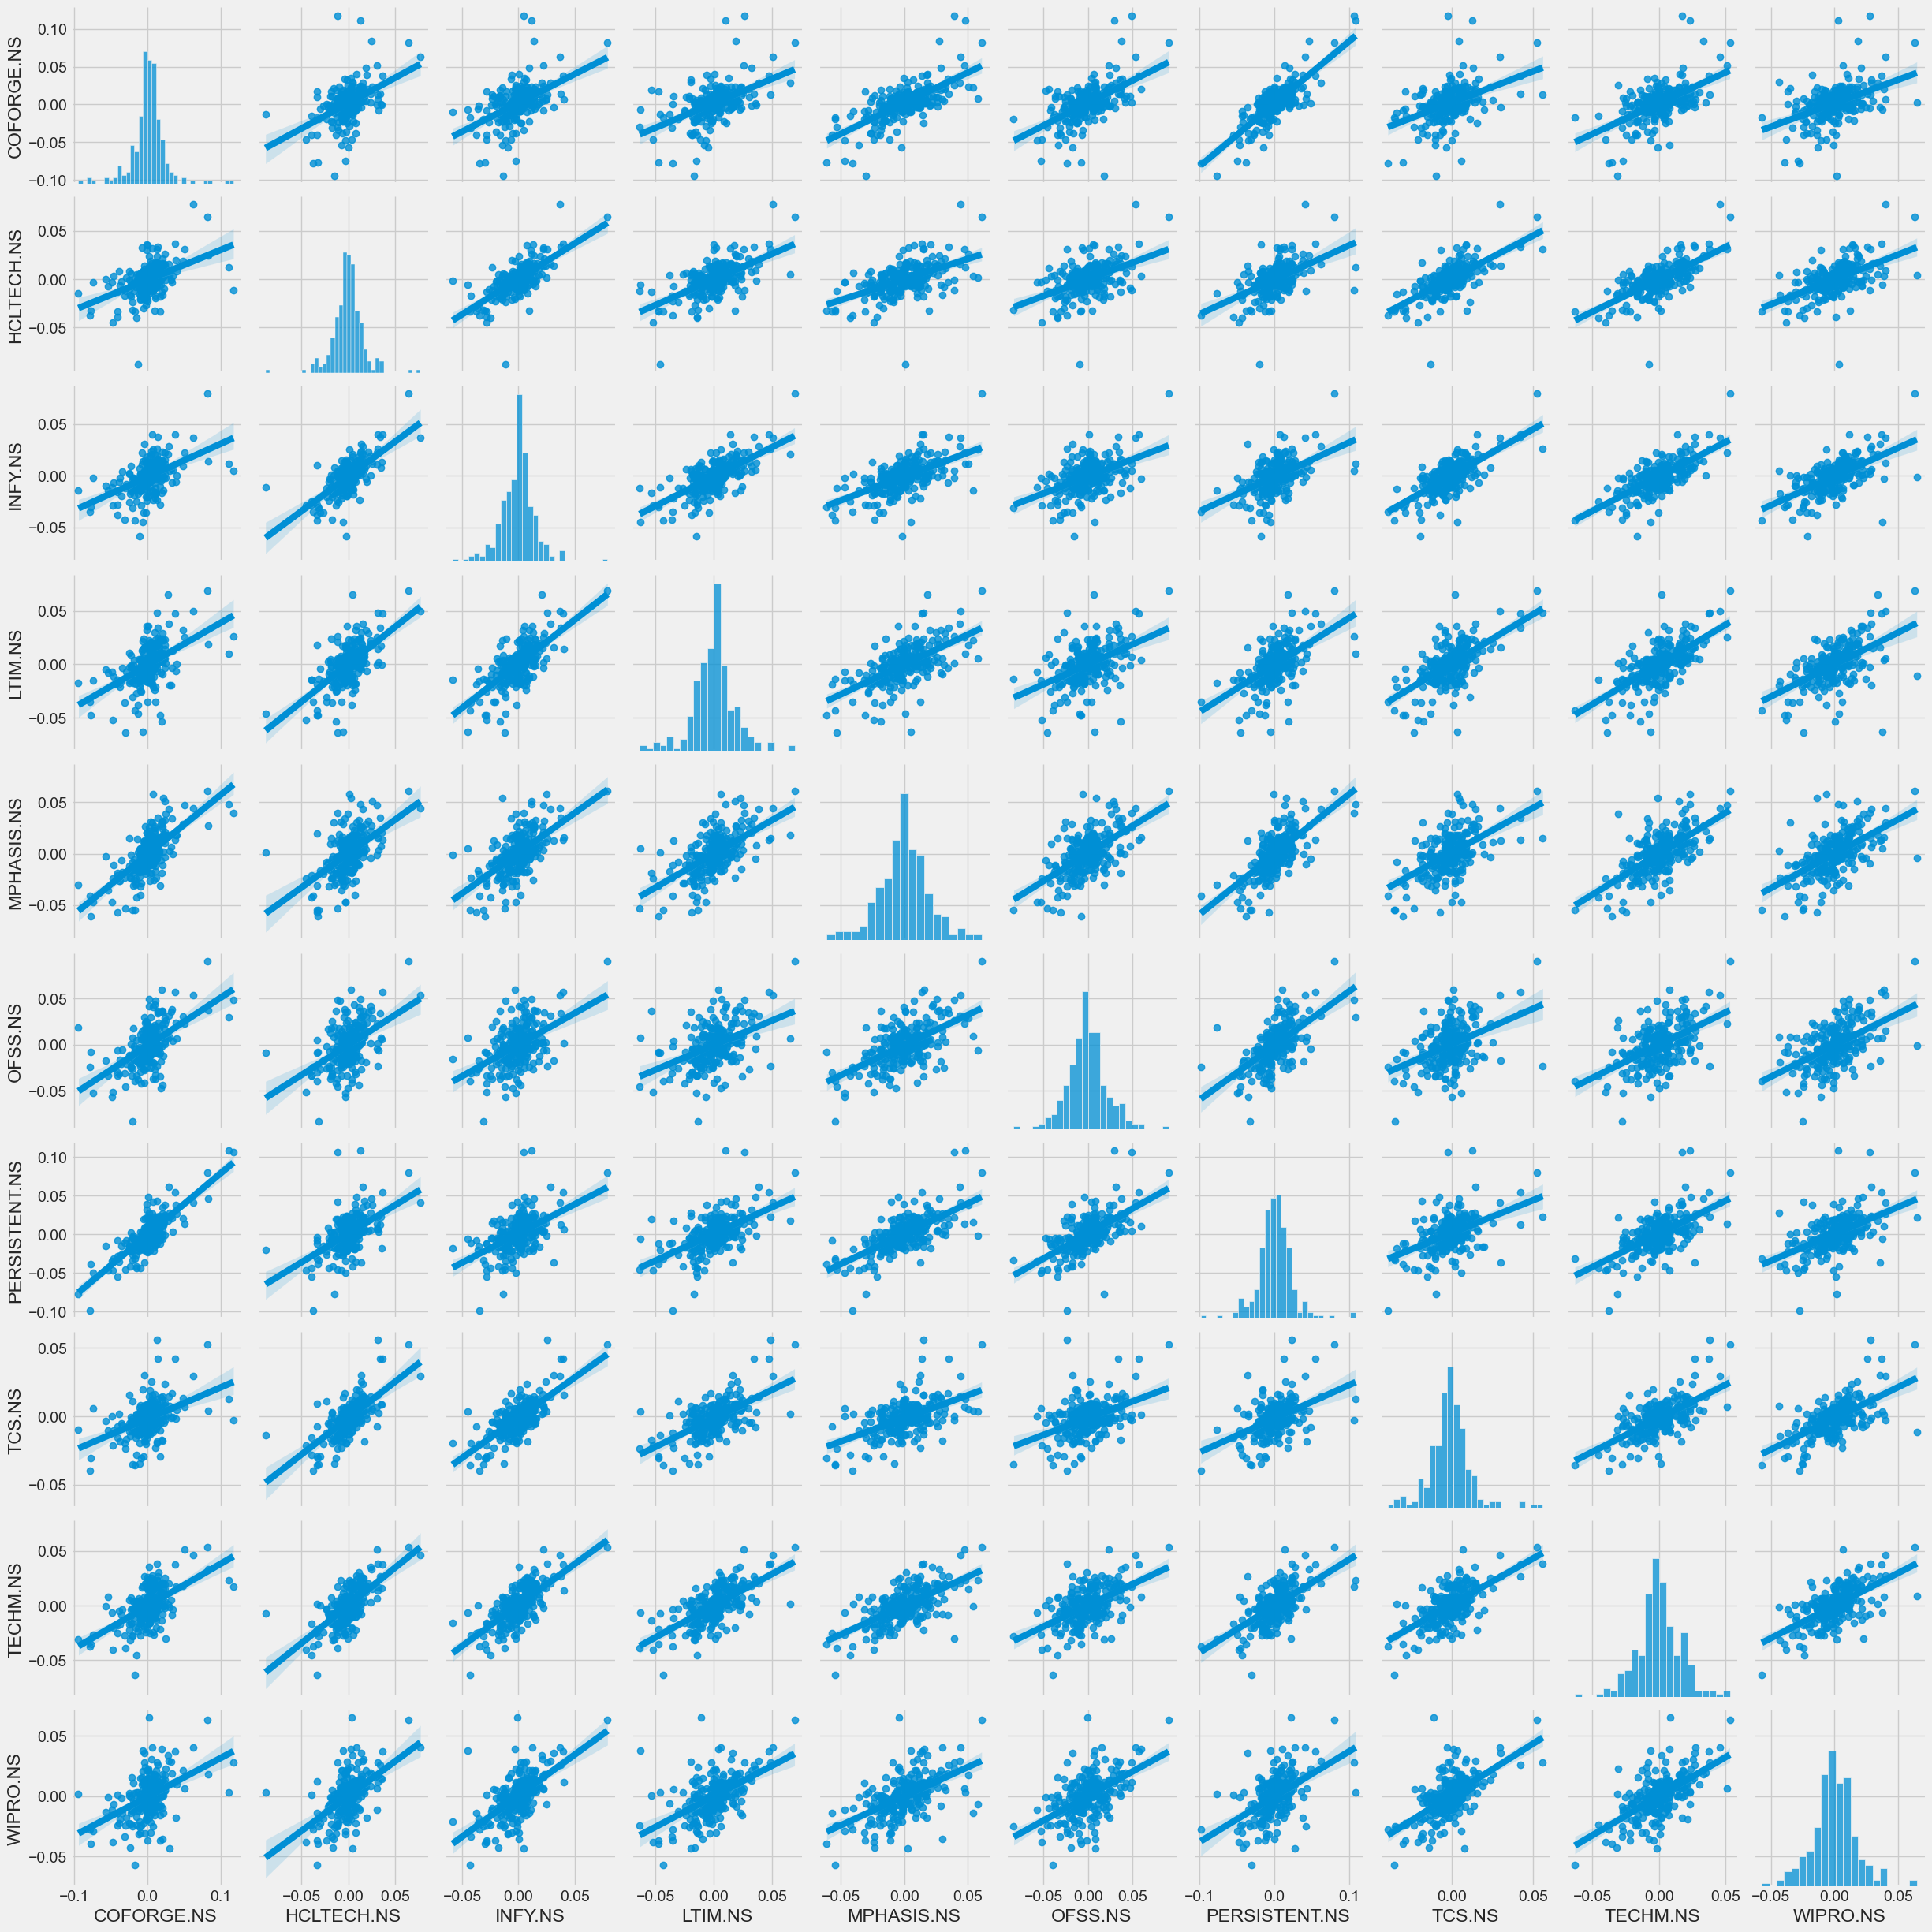

In [62]:
sns.pairplot(tech_rets, kind='reg')

Text(0.5, 1.0, 'Correlation of stock closing price')

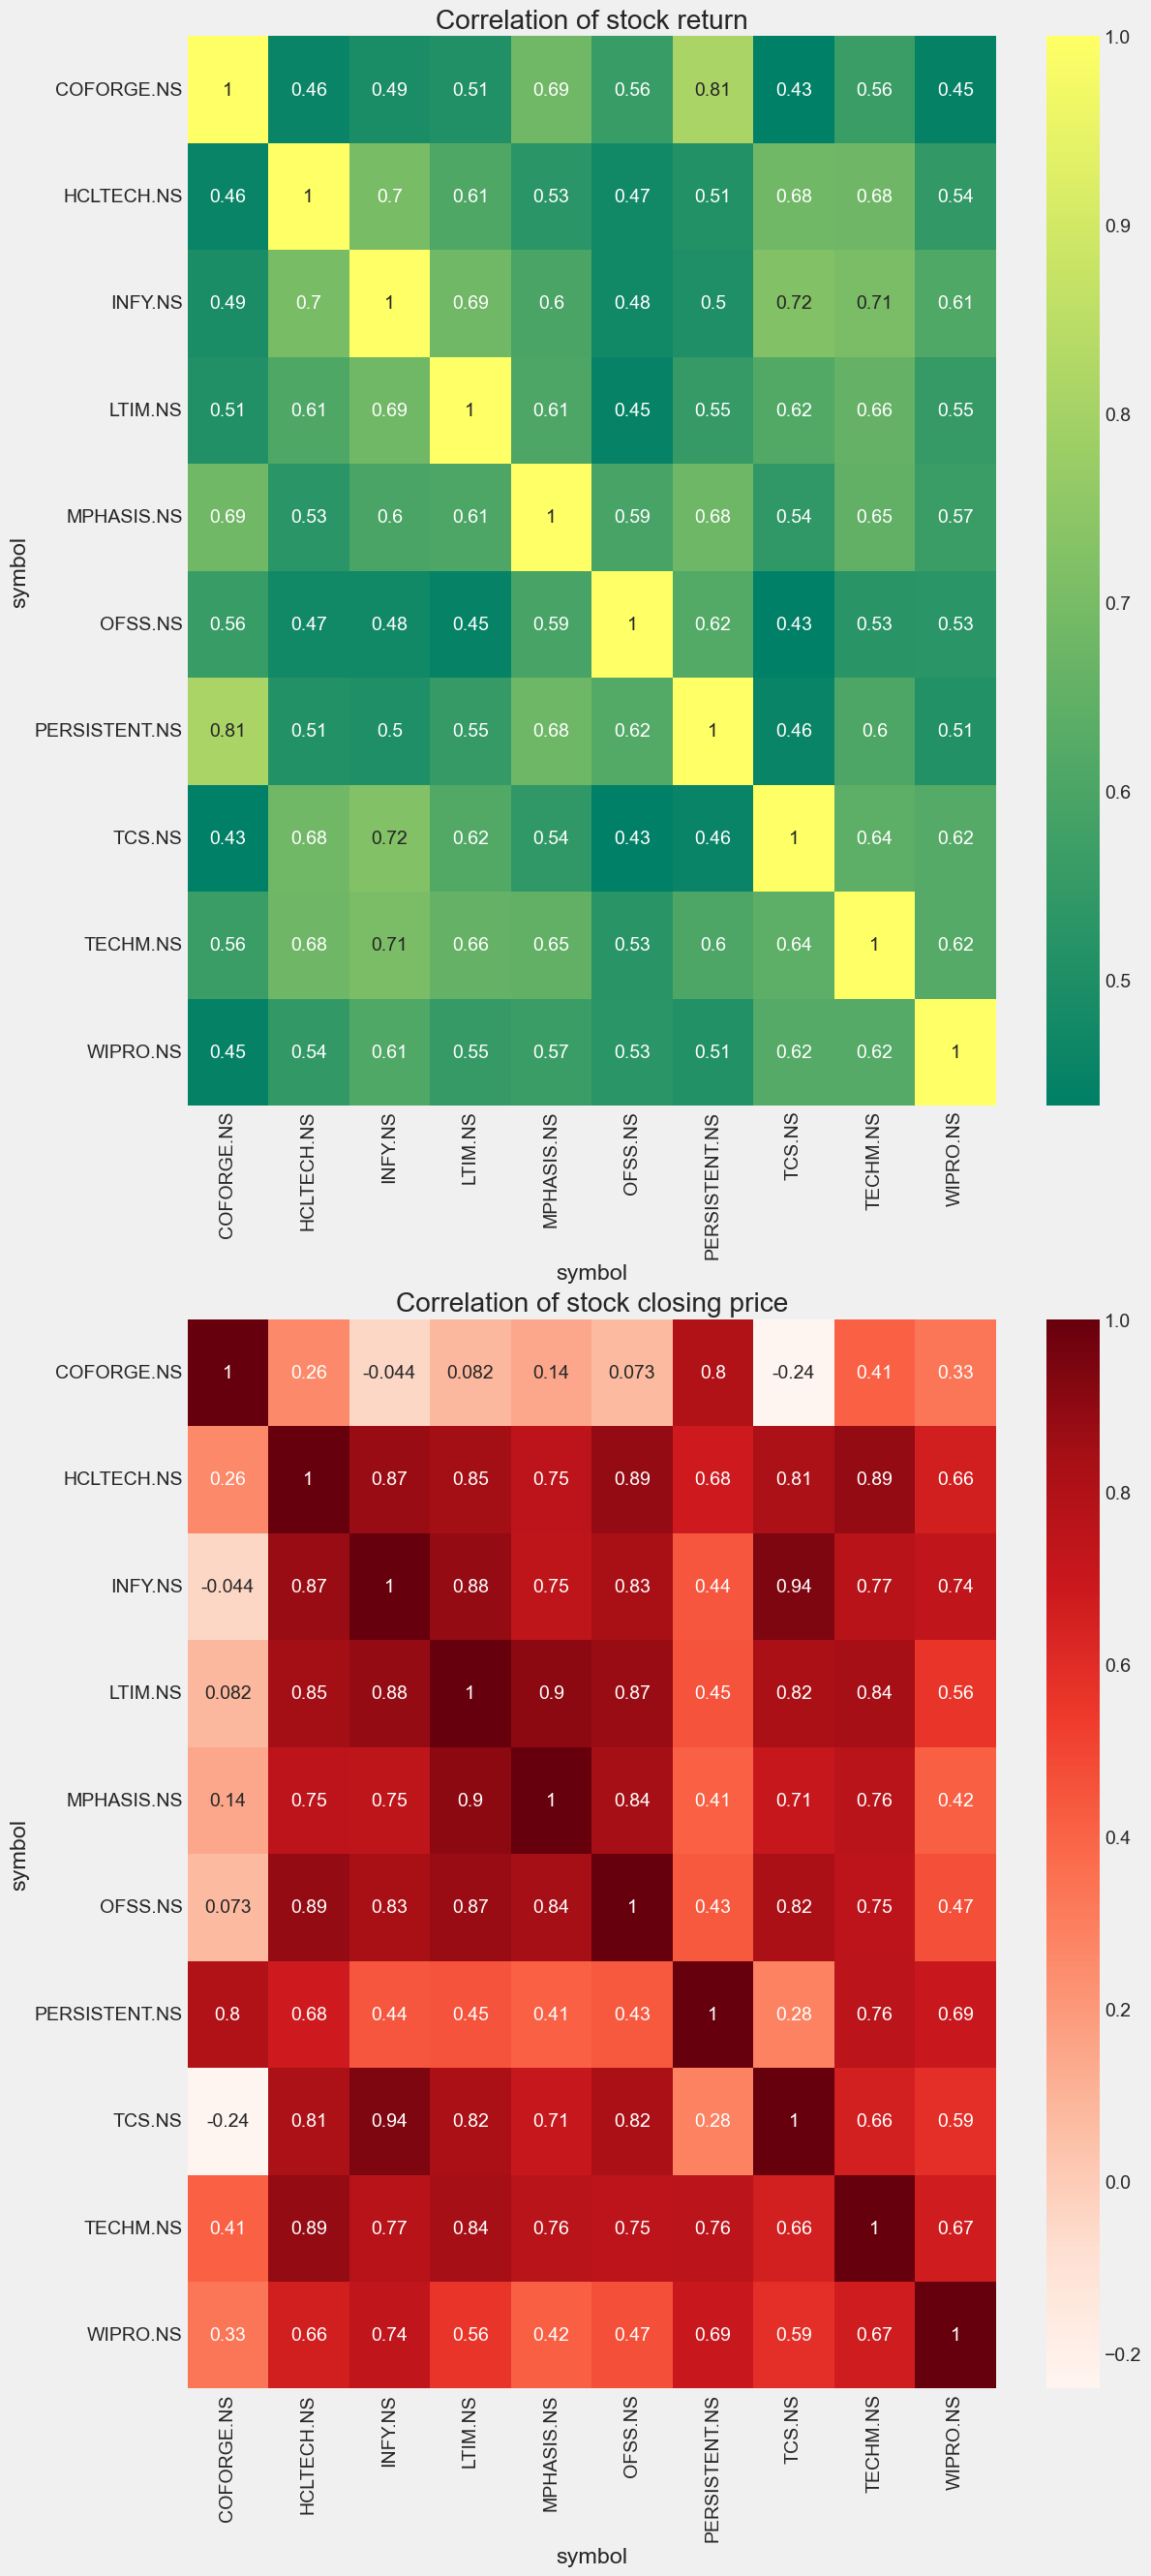

In [63]:
plt.figure(figsize=(12, 30))

plt.subplot(2, 1, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2, 1, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='Reds')
plt.title('Correlation of stock closing price')

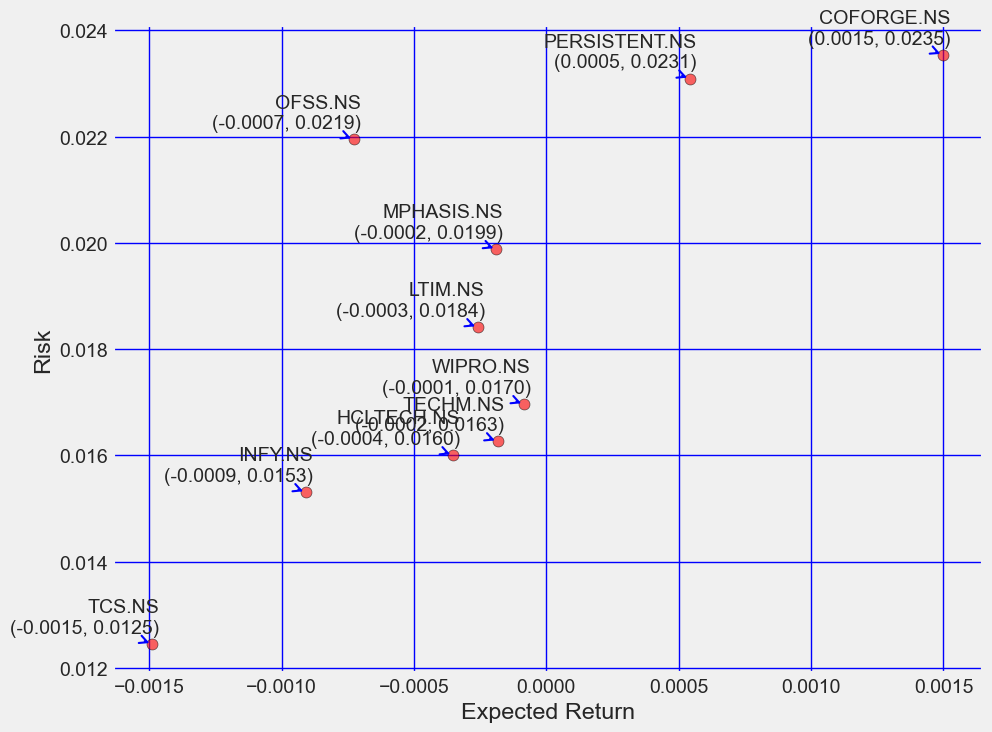

In [ ]:

rets = tech_rets.dropna()
area = np.pi * 20
plt.figure(figsize=(10, 8))
# Scatter plot: expected (mean returns), risk (standard deviation)
plt.scatter(rets.mean(), rets.std(), s=area, color='red', alpha=0.6, edgecolors="black")
plt.xlabel('Expected Return')
plt.ylabel('Risk')
plt.grid(True, which='both',color='blue', linewidth=1, alpha=1)
for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(f"{label}\n({x:.4f}, {y:.4f})", xy=(x, y), xytext=(5, 5),
                 textcoords='offset points', ha='right', va='bottom',
                 arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
plt.show()


We have by now analysed 10 different stocks and realised their different characteristics.
Now its time to choose any one among them to perform Further analysis.
Wipro offers good returns with low risk, so lets move ahead and analyze wipro.

In [65]:
tickers=['WIPRO.NS']
start_date='2005-01-01'
end_date=datetime.now().strftime("%Y-%m-%d")
t=Ticker(tickers)
df=t.history(start=start_date,end=end_date)
df=df.reset_index()
df=df[['symbol','date','open','high','low','close','volume']]
print(df.head())

     symbol        date       open       high        low      close  \
0  WIPRO.NS  2005-01-03  42.468754  42.581253  41.940002  42.423752   
1  WIPRO.NS  2005-01-04  42.468754  42.750004  40.781254  42.134064   
2  WIPRO.NS  2005-01-05  41.850002  41.850002  39.431252  39.785625   
3  WIPRO.NS  2005-01-06  39.768749  40.218754  38.531250  38.778751   
4  WIPRO.NS  2005-01-07  38.812500  39.487499  38.652187  39.360939   

       volume  
0   7628977.0  
1   7618292.0  
2  26921936.0  
3  24126398.0  
4  13164106.0  


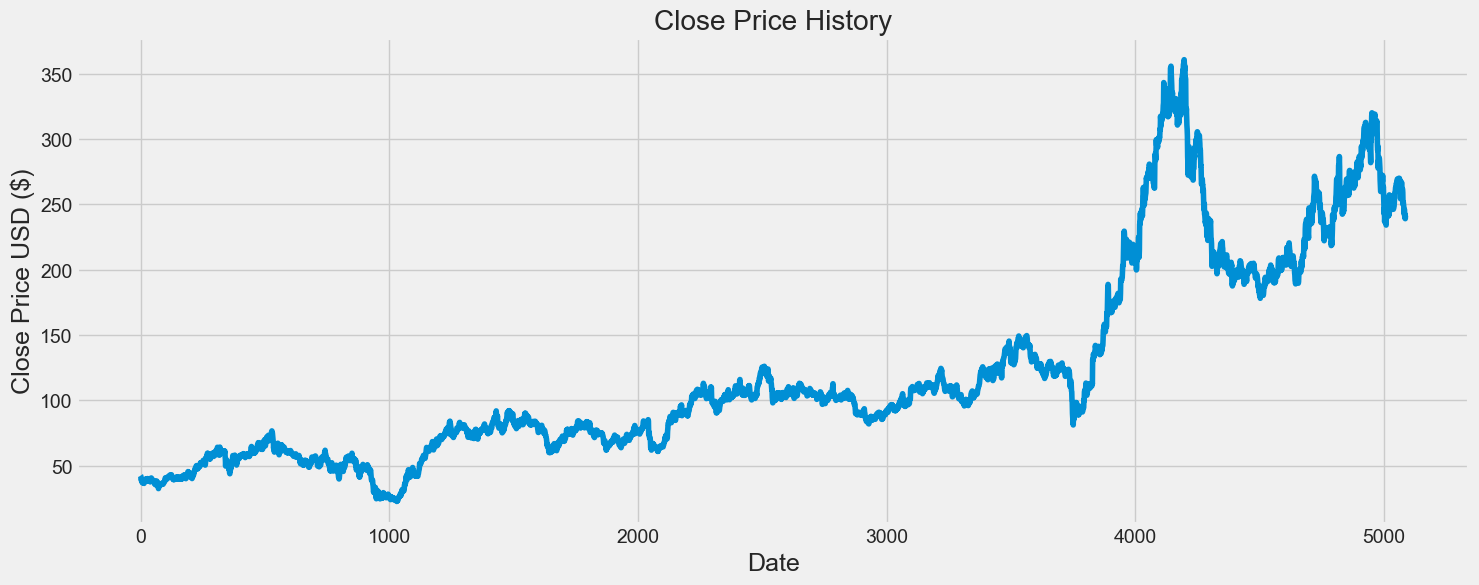

In [66]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [67]:
print(df.columns)
data=df.filter(['close'])
print(data.columns)
dataset=data.values
training_data_len = int(np.ceil( len(dataset) * .95 ))
training_data_len

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
Index(['close'], dtype='object')


4835

(X-Xmin)/(Xmax-Xmin) is the formula for scaling!

In [ ]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler
dataset = df[["close"]].values
# Initialize and apply MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)
print("This is unscaled data")
print(dataset)
print("This is scaled data")
print(scaled_data)

This is unscaled data
[[ 42.42375183]
 [ 42.13406372]
 [ 39.78562546]
 ...
 [241.61999512]
 [241.72000122]
 [241.6499939 ]]
This is scaled data
[[0.05862065]
 [0.05776396]
 [0.05081898]
 ...
 [0.64769941]
 [0.64799515]
 [0.64778812]]


In [ ]:

train_data = scaled_data[0:int(training_data_len), :]
x_train = []
y_train = []
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
print(x_train)

[[0.05862065]
 [0.05776396]
 [0.05081898]
 [0.04784137]
 [0.04956306]
 [0.04594501]
 [0.04559568]
 [0.04228538]
 [0.04474732]
 [0.04371597]
 [0.04547093]
 [0.04662704]
 [0.04763344]
 [0.04538775]
 [0.04092134]
 [0.04240183]
 [0.04539608]
 [0.04935513]
 [0.0504946 ]
 [0.04898084]
 [0.04730906]
 [0.04865647]
 [0.05012864]
 [0.04767502]
 [0.04846517]
 [0.04819902]
 [0.0470845 ]
 [0.0488145 ]
 [0.05187529]
 [0.05071086]
 [0.05075244]
 [0.04935513]
 [0.04814911]
 [0.04605314]
 [0.04685161]
 [0.0461779 ]
 [0.04584521]
 [0.04506337]
 [0.04952147]
 [0.0455541 ]
 [0.04479722]
 [0.04903075]
 [0.05293991]
 [0.05323933]
 [0.0525074 ]
 [0.05185865]
 [0.0503532 ]
 [0.04920542]
 [0.04859826]
 [0.04689319]
 [0.04676843]
 [0.04618622]
 [0.04727579]
 [0.0470845 ]
 [0.04564559]
 [0.04223548]
 [0.04052211]
 [0.04015614]
 [0.03982345]
 [0.03801858]]


In [89]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=5)

C:\Users\moksh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
4775/4775 ━━━━━━━━━━━━━━━━━━━━ 86s 17ms/step - loss: 0.0015
Epoch 2/5
4775/4775 ━━━━━━━━━━━━━━━━━━━━ 90s 19ms/step - loss: 3.4280e-04
Epoch 3/5
4775/4775 ━━━━━━━━━━━━━━━━━━━━ 95s 20ms/step - loss: 2.3274e-04
Epoch 4/5
4775/4775 ━━━━━━━━━━━━━━━━━━━━ 94s 20ms/step - loss: 1.9879e-04
Epoch 5/5
4775/4775 ━━━━━━━━━━━━━━━━━━━━ 94s 20ms/step - loss: 1.4145e-04


In [ ]:
# Create the testing data set
test_data = scaled_data[training_data_len - 60: , :]
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 )) 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)
# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step


np.float64(4.711259249329502)

C:\Users\moksh\AppData\Local\Temp\ipykernel_5944\3654442949.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


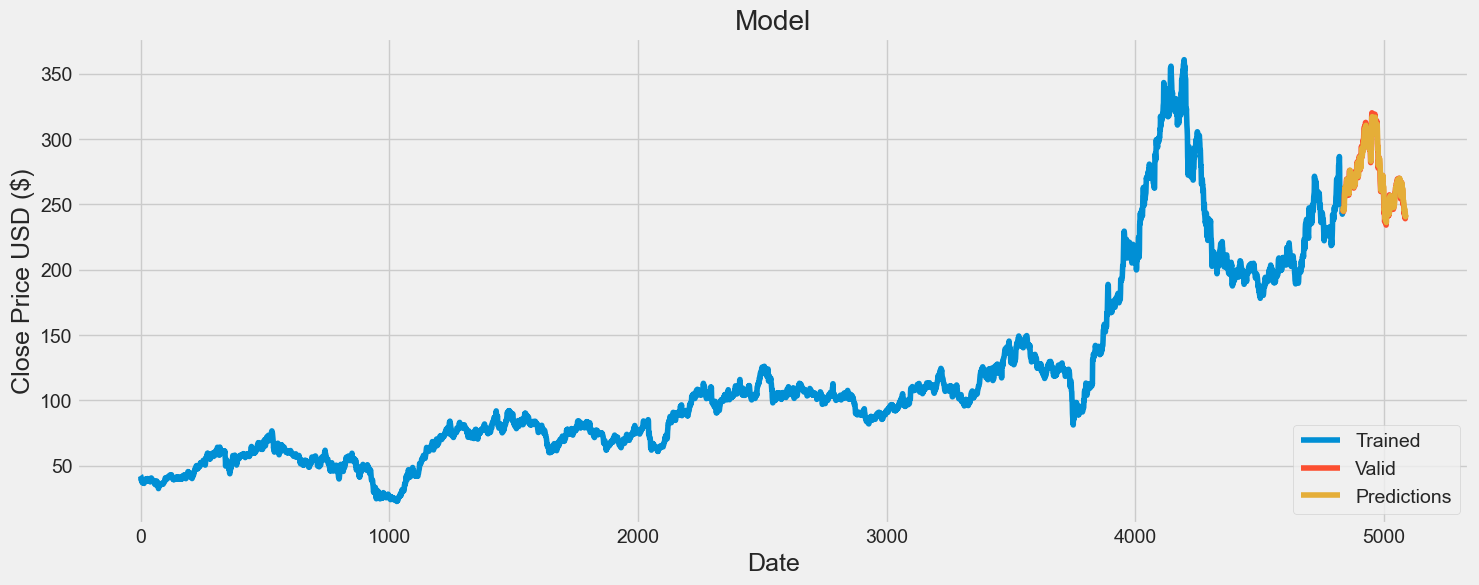

In [91]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['close'])
plt.plot(valid[['close', 'Predictions']])
plt.legend(['Trained', 'Valid', 'Predictions'], loc='lower right')
plt.show()

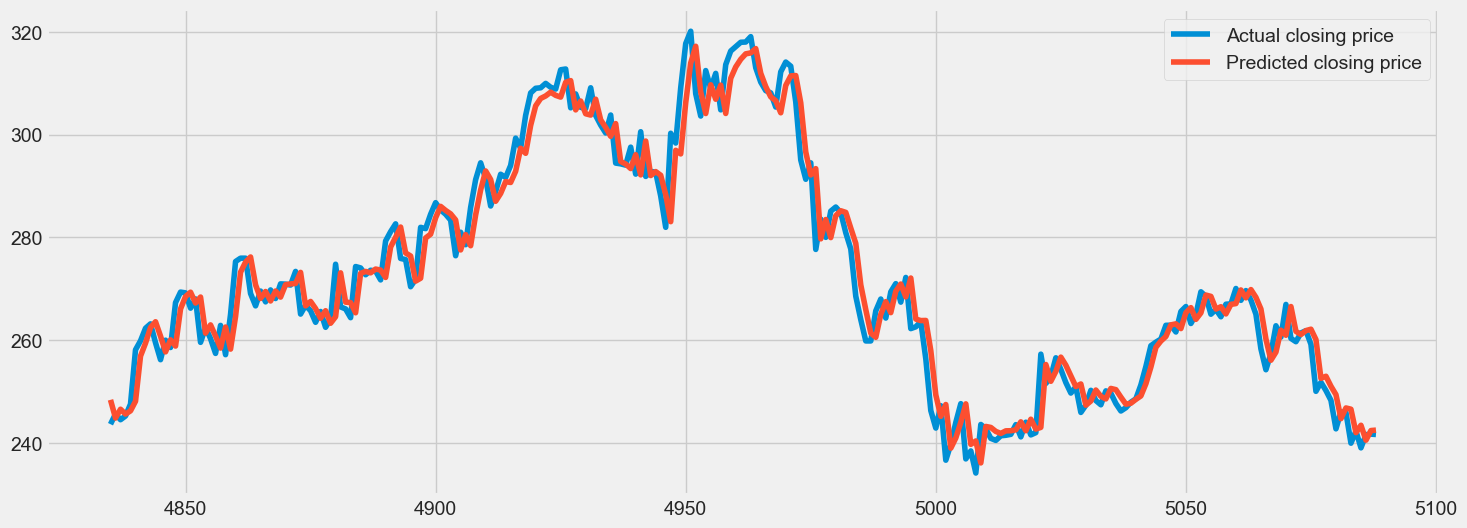

In [92]:
plt.figure(figsize=(16,6))
plt.plot(valid[['close', 'Predictions']])
plt.legend(['Actual closing price','Predicted closing price'])